# **OpenCV Mouse Event Handling — Interactive Drawing Tools**

A set of exercises exploring (`cv2.setMouseCallback()`) to build interactive drawing tools: a freehand brush, a pen/line tool, and rectangle tools with live preview, undo, and reset. Each exercise builds on the previous one's concepts.

Core idea used throughout: OpenCV's event loop only processes mouse events when cv2.waitKey() is called, so every one of these scripts needs a while True loop calling waitKey(1) to stay responsive. The mouse callback function receives the event type (EVENT_LBUTTONDOWN, EVENT_MOUSEMOVE, EVENT_LBUTTONUP, etc.) and the cursor's (x, y) position every time the mouse state changes.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Creates a blank white canvas as a NumPy array. np.ones(...) * 255 fills every pixel with 255 (white) across all channels — the standard way to generate a blank canvas without loading an image file. Used as the drawing surface for the exercises below instead of cv2.imread().

In [9]:
def create_screen(height, width, channels, dtype=np.uint8):
    return np.ones((height, width, channels), dtype=dtype) * 255

## **1. Freehand Brush**

What it does: Simulates a paintbrush. A drawing flag is turned on while the left mouse button is held down. While drawing is True, every mouse-move event stamps a small filled circle directly onto the canvas at the cursor's position, building up a continuous stroke as the user drags.

Key concept: THICKNESS = -1 tells OpenCV to fill the shape instead of drawing only its outline — the same flag works for circles, rectangles, and other shapes. The drawing boolean is a simple state gate: without it, moving the mouse over the canvas (without clicking) would draw too.

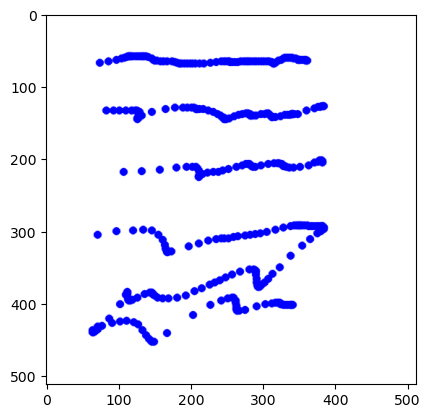

In [10]:
drawing = False
RADIUS = 5
COLOR = (255, 0, 0)
THICKNESS = -1

def brush(event, x, y, flags, params):
    global drawing, RADIUS, COLOR, THICKNESS
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.circle(screen, (x, y), RADIUS, COLOR, THICKNESS, lineType=cv2.LINE_AA)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

screen = create_screen(512, 512, 3)

cv2.namedWindow("Window1")
cv2.setMouseCallback("Window1", brush)

while True:
    cv2.imshow("Window1", screen)
    if cv2.waitKey(1) & 0xff == 27:
        break

cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

## **2. Brush with Color Switching**

What it does: Same brush mechanic as Exercise 1, but the active drawing color can be changed at runtime by pressing b, g, or r on the keyboard.

Key concept: This demonstrates communication between the main loop and the callback function through a shared global variable — the keyboard loop writes to color, and the mouse callback reads from it. This is the same pattern behind any "tool palette" UI: pick a color/tool/size elsewhere in the program, then use it inside the drawing function.

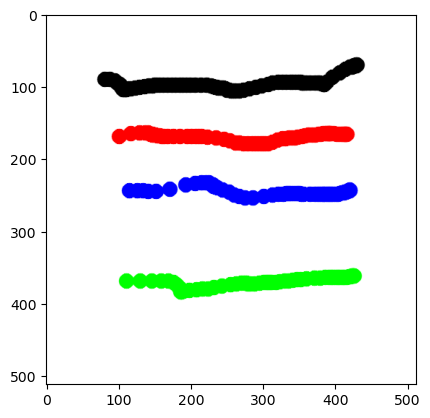

In [11]:
drawing = False
RADIUS = 10
color = (0, 0, 0)
THICKNESS = -1

def brush(event, x, y, flags, params):
    global drawing, RADIUS, color, THICKNESS
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.circle(screen, (x, y), RADIUS, color, THICKNESS, lineType=cv2.LINE_AA)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

screen = create_screen(512, 512, 3)

cv2.namedWindow("Window2")
cv2.setMouseCallback("Window2", brush)

while True:
    cv2.imshow("Window2", screen)
    key = cv2.waitKey(1) & 0xff

    if key == ord("b"):
        color = (255, 0, 0)
    elif key == ord("g"):
        color = (0, 255, 0)
    elif key == ord("r"):
        color = (0, 0, 255)
    elif key == ord("q"):
        break

cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

## **3. Freehand Line (Pen Tool)**

What it does: Draws a smooth freehand curve rather than stamped circles. On every mouse-move while dragging, it draws a short straight segment from the previous recorded point to the current cursor position, then updates point to the current position so the next segment continues from there.

Key concept: A single cv2.line() call can only draw one straight segment. By continuously updating point and drawing many tiny segments in sequence, the tool approximates a smooth curve — the same principle used by real pen/stylus input and vector-drawing tools.

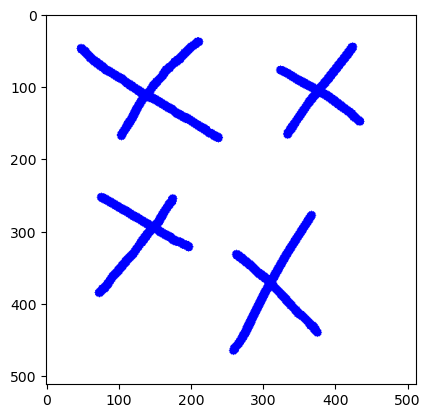

In [12]:
drawing = False
point = None
COLOR = (255, 0, 0)
THICKNESS = 12

def draw_line(event, x, y, flags, params):
    global drawing, point

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        point = (x, y)
    
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.line(screen, point, (x, y), COLOR, THICKNESS)
        point = (x, y)
    
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        
screen = create_screen(512, 512, 3)

cv2.namedWindow("Window3")
cv2.setMouseCallback("Window3", draw_line)

while True:
    cv2.imshow("Window3", screen)
    if cv2.waitKey(1) & 0xff == 27:
        break

cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()        

## **4. Rectangle Tool — Live-Drawn, No Preview Buffer**

What it does: Draws a filled rectangle straight onto the permanent screen array on every mouse-move event during the drag — there is no disposable scratch copy involved. Because the rectangle is filled (THICKNESS = -1), each mouse-move permanently stamps a new overlapping rectangle at the current cursor position directly into the real canvas. The in-progress rectangle from the previous frame is never cleared before the next one is drawn — it just keeps compounding on top of itself.

What you'll see if you run it: Instead of one clean, resizable box, you get a stacked trail or "fan" of overlapping rectangles left behind from every intermediate cursor position during the drag. This happens because nothing about this version distinguishes "a rectangle I'm still adjusting" from "a rectangle I'm done with" — both cases draw permanently onto the same buffer.

Key concept — shared buffer, compounding draws: Any tool that draws directly onto its final canvas on every single mouse-move event will accumulate every intermediate frame permanently, not just the last one. This is fine (even desirable) for a brush stroke — see Exercise 1 — where the compounding is the effect you want. It's not fine for a shape tool meant to represent one clean, adjustable box.

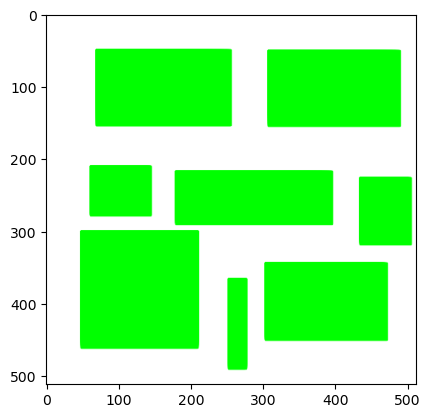

In [13]:
drawing = False
start_point = None
COLOR = (0, 255, 0)
THICKNESS = -1

def draw_rectangle(event, x, y, flags, params):
    global drawing, start_point
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        start_point =(x, y)
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.rectangle(screen, start_point, (x, y), COLOR, THICKNESS, lineType=cv2.LINE_AA)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

screen = create_screen(512, 512, 3) 

cv2.namedWindow("Window4")
cv2.setMouseCallback("Window4", draw_rectangle)

while True:
    cv2.imshow("Window4", screen)
    if cv2.waitKey(1) & 0xff == 27:
        break

cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

## **5. Rectangle Tool — With a Preview Buffer**

What it does: On every mouse-move event, it takes a fresh copy of screen (temp = screen.copy()) — which at this point still only contains whatever was already committed before this drag started — draws the preview rectangle onto that copy, and displays the copy with cv2.imshow(). The real screen array is left completely untouched throughout the entire drag. Only once, on EVENT_LBUTTONUP, does the rectangle actually get drawn onto screen and become permanent.

What you'll see if you run it: A single, clean rectangle that resizes smoothly as you drag, with no trail left behind — because every frame's preview is built fresh from the same untouched base image (screen) rather than being drawn on top of the previous frame's preview.

Key concept — preview state vs. committed state: Keeping "in-progress" drawing (temp) separate from "finished" drawing (screen) is what allows a live preview to update every frame without any of those intermediate frames becoming permanent. screen only ever holds finished shapes; temp is a throwaway canvas rebuilt fresh every single frame. This is the same idea behind autosave-safe editors and non-destructive image editing generally, and it's required any time a filled shape — or any shape redrawn at high frequency — needs a live preview while the user adjusts it.

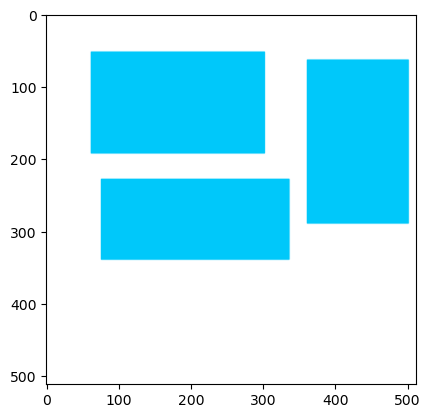

In [22]:
drawing = False
start_point = None
COLOR = (250, 200, 0)
THICKNESS = -1

def draw_rectangle(event, x, y, flags, params):
    global drawing, start_point, COLOR, THICKNESS

    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        
        temp = screen.copy()
        cv2.rectangle(temp, start_point, (x,y), COLOR, THICKNESS, lineType=cv2.LINE_AA)
        cv2.imshow("Window5", temp)
    
    elif event == cv2.EVENT_LBUTTONUP:
        cv2.rectangle(screen, start_point, (x,y), COLOR, THICKNESS, lineType=cv2.LINE_AA)
        drawing = False

screen = create_screen(512, 512, 3)

cv2.namedWindow("Window5")
cv2.setMouseCallback("Window5", draw_rectangle)

while True:
    cv2.imshow("Window5", screen)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break

cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()

## **6. Rectangle Tool — Commit on Release, with Reset**

What it does: No live preview — the rectangle only appears once the mouse button is released. Every finished rectangle's corner coordinates are stored in the points list. Pressing r restores the canvas from temp (an untouched backup made right after loading the image) and clears points, resetting everything.

Key concept — non-destructive editing: Because cv2.rectangle() permanently modifies pixel data in-place, you need an untouched backup copy to "undo" back to a clean state — you can't reverse pixel changes directly. Keeping a points list is also what makes reset and future undo features possible: it's a record of every action taken, separate from the rendered image itself.

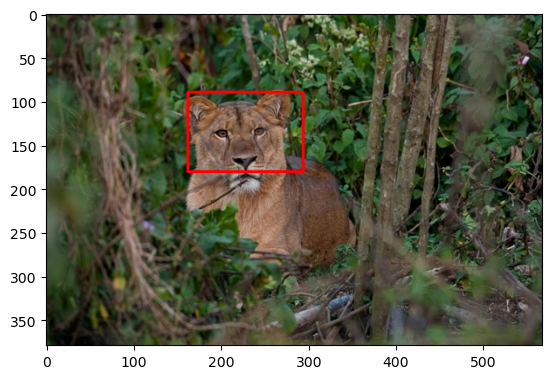

In [17]:
points = []
start_point = None
COLOR = (0, 0, 255)
THICKNESS = 2

def draw_rectangle(event, x, y, flags, params):
    global points, start_point, COLOR, THICKNESS
    
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
    
    elif event == cv2.EVENT_LBUTTONUP:
        points.append([start_point, (x, y)])
        cv2.rectangle(screen, start_point, (x, y), COLOR, THICKNESS, lineType=cv2.LINE_AA)

        
screen = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\02s\pic2\006.jpg")
temp = screen.copy()

cv2.namedWindow("Window6")
cv2.setMouseCallback("Window6", draw_rectangle)

while True:
    cv2.imshow("Window6", screen)
    key = cv2.waitKey(1) & 0xff

    if key == ord("r"):
        screen = temp.copy()
        points = []
         
    if key == ord("q"):
        break
        
cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()  

## **7. Rectangle Tool — Live Preview + Single-Step Undo + Reset**

What it does: The complete version. While dragging, every mouse-move copies the already-committed screen into a disposable temp variable, draws a preview rectangle onto that copy only, and shows it — so the real screen is never touched until the mouse is released. On release, the rectangle is drawn permanently onto screen and its coordinates saved to points. Pressing z removes only the most recently drawn rectangle: it rebuilds the canvas from the clean backup and replays every remaining rectangle in points. Pressing r clears everything back to a blank canvas.

Key concepts combined:

Preview vs. commit separation (fixes the bug from Exercise 4): temporary state is drawn on a scratch copy; only finalized shapes touch the real canvas.
Action history as source of truth: points is a list of every committed action. Undo is just "remove the last action, then replay all remaining ones from a clean base" — the same principle behind undo/redo systems in real editors and version control.
points.pop() vs points = []: .pop() removes only the last item (single-step undo); reassigning to [] clears everything (full reset). Mixing these two up (e.g. a variable name typo like point vs points) is a common, silent bug — Python won't error, it'll just create an unused variable and leave the real list untouched.

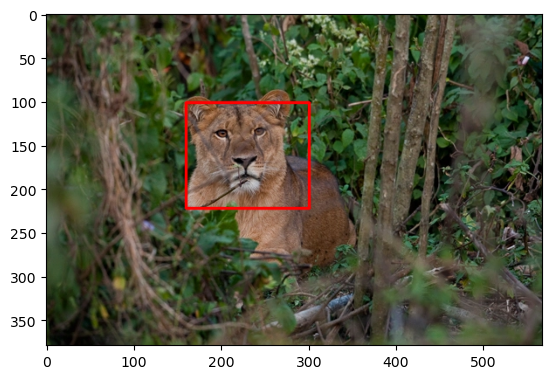

In [18]:
drawing = False
points = []
start_point = None
COLOR = (0, 0, 255)
THICKNESS = 2

def draw_rectangle(event, x, y, flags, params):
    global drawing, points, start_point, COLOR, THICKNESS
    
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
        drawing = True

    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        temp = screen.copy()
        cv2.rectangle(temp, start_point, (x, y), COLOR, THICKNESS, lineType=cv2.LINE_AA)
        cv2.imshow("Window7", temp)
        
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        cv2.rectangle(screen, start_point, (x, y), COLOR, THICKNESS, lineType=cv2.LINE_AA)
        points.append([start_point, (x, y)])

        
screen = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\02s\pic2\006.jpg")
temp = screen.copy()

cv2.namedWindow("Window7")
cv2.setMouseCallback("Window7", draw_rectangle)

while True:  
    
    cv2.imshow("Window7", screen)
    key = cv2.waitKey(1) & 0xff

    if key == ord("r"):
        screen = temp.copy()
        points = []

    if key == ord("z"):
        screen = temp.copy() 
        if points:
            points.pop()
            for p in points:
                cv2.rectangle(screen, p[0], p[1], COLOR, THICKNESS, lineType=cv2.LINE_AA)   
            
    if key == ord("q"):
        break
        
cv2.destroyAllWindows()

plt.imshow(screen[..., ::-1])
plt.show()  